In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures, StandardScaler
import warnings
from sklearn.exceptions import ConvergenceWarning
import numpy as np
import optuna

In [2]:
data = pd.read_csv("../../data/Data_for_UCI_named.csv")

In [3]:
data.head(10)

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable
5,6.999209,9.109247,3.784066,4.267788,4.429669,-1.857139,-0.670397,-1.902133,0.261793,0.077930,0.542884,0.469931,-0.017385,stable
6,6.710166,3.765204,6.929314,8.818562,2.397419,-0.614590,-1.208826,-0.574004,0.177890,0.397977,0.402046,0.376630,0.005954,unstable
7,6.953512,1.379125,5.719400,7.870307,3.224495,-0.748998,-1.186517,-1.288980,0.371385,0.633204,0.732741,0.380544,0.016634,unstable
8,4.689852,4.007747,1.478573,3.733787,4.041300,-1.410344,-1.238204,-1.392751,0.269708,0.250364,0.164941,0.482439,-0.038677,stable
9,9.841496,1.413822,9.769856,7.641616,4.727595,-1.991363,-0.857637,-1.878594,0.376356,0.544415,0.792039,0.116263,0.012383,unstable


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [5]:
data.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [6]:
(data.isna().sum()/data.shape[0]*100).sort_values(ascending=False)

tau1     0.0
tau2     0.0
tau3     0.0
tau4     0.0
p1       0.0
p2       0.0
p3       0.0
p4       0.0
g1       0.0
g2       0.0
g3       0.0
g4       0.0
stab     0.0
stabf    0.0
dtype: float64

### Визуальный анализ данных

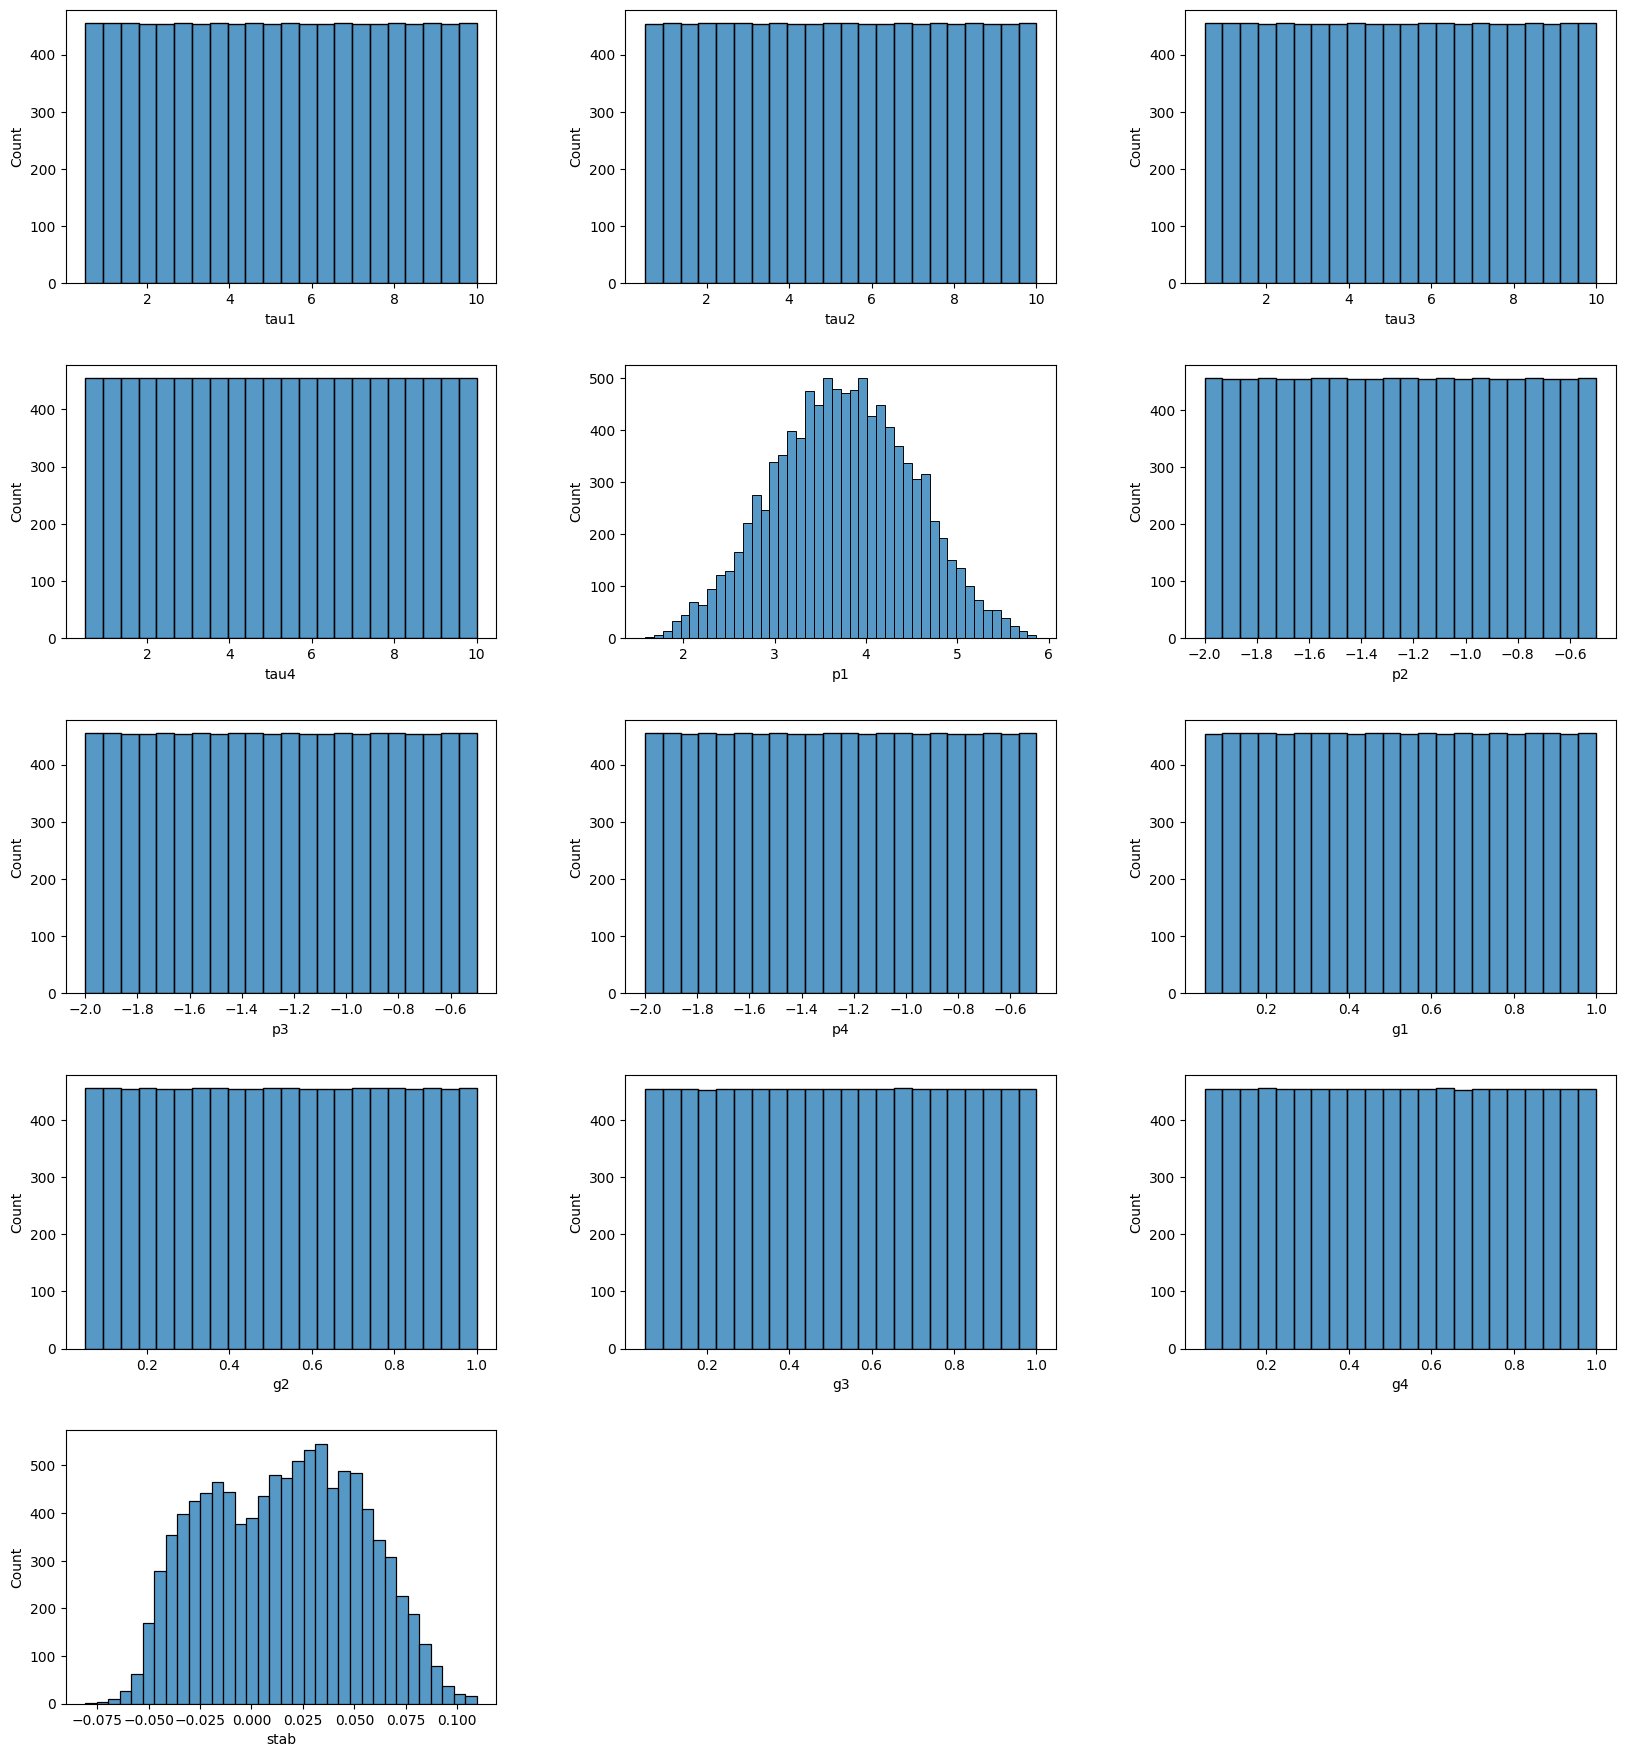

In [7]:
numeric_columns = [col for col in data.select_dtypes(include=['number']).columns if col != 'stabf']
fig, ax = plt.subplots(5, 3, figsize=(20, 22))  
axes = ax.flatten()

for i, column in enumerate(numeric_columns):
    sns.histplot(data=data[column], ax=axes[i])

plt.subplots_adjust(wspace=0.3, hspace=0.3)
axes[-1].set_visible(False)
axes[-2].set_visible(False)
plt.show()

- **Время реакции (tau)** для производителя и потребителей равномерно распределено от 0 до 10.
- **Мощности потребителей (p)** равномерно лежат в диапазоне от –2 до –0.5.
- **Ценовая эластичность (g)** для всех участников равномерно распределена от 0 до 1.
- **Мощность производителя (p1)** имеет распределение, близкое к нормальному, и находится в пределах от 1.6 до 5.9.
- **Медиана показателя стабильности (stab) равна 0.017** — это означает, что **более чем в половине случаев система является нестабильной**.

### Анализируем выбросы

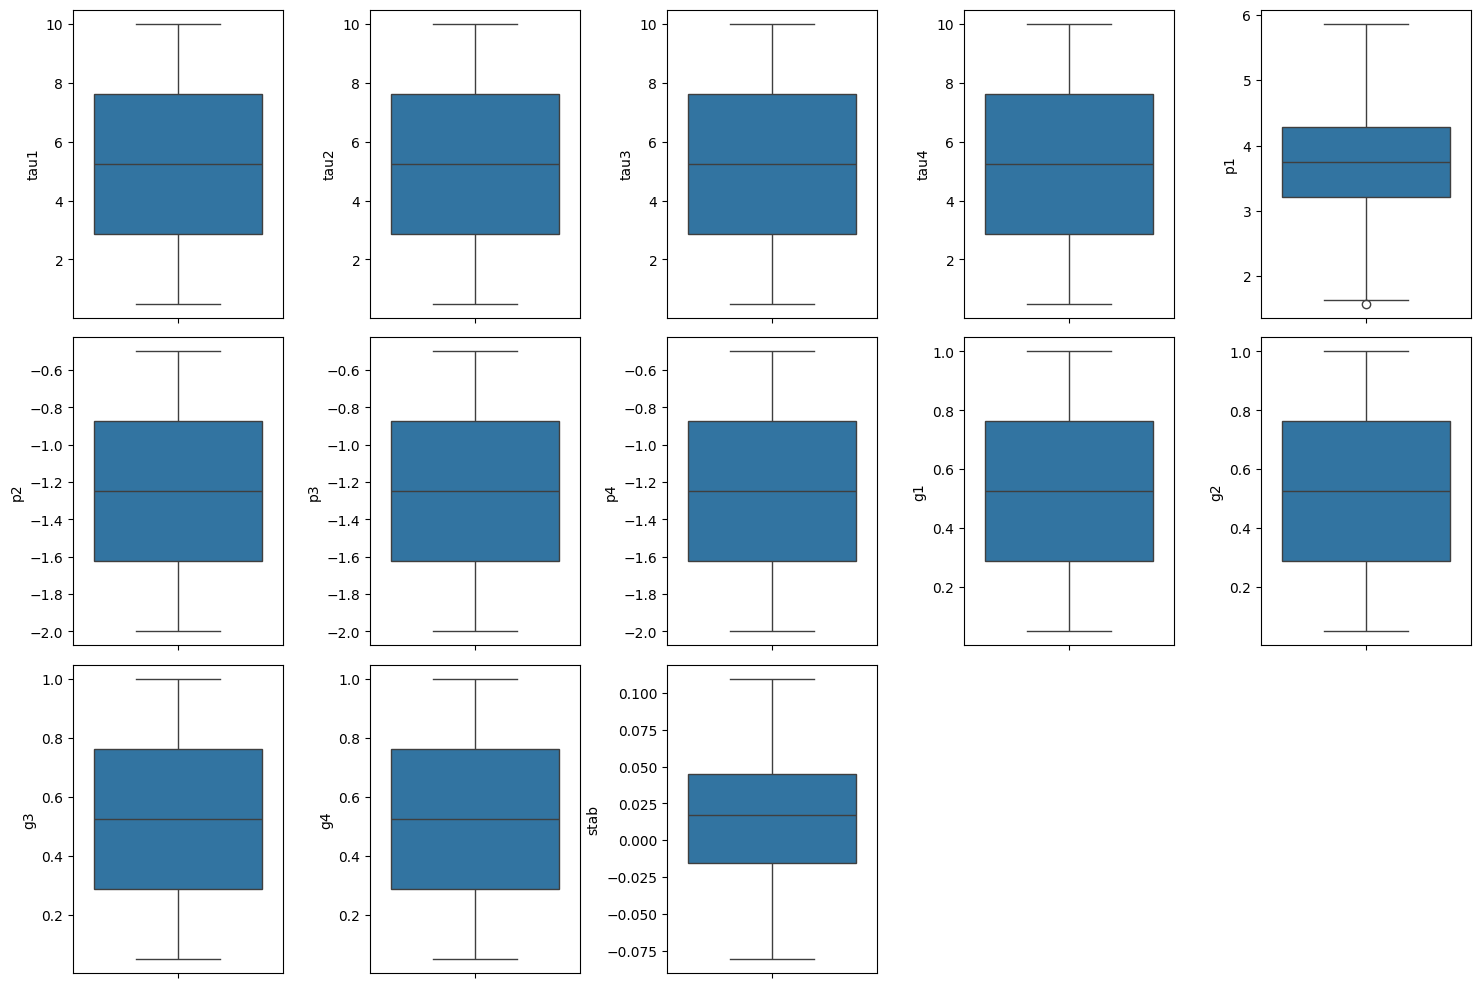

In [8]:
fig, ax = plt.subplots(3, 5, figsize=(15, 10))
axes = ax.flatten()

for i, column in enumerate(numeric_columns):
    sns.boxplot(y=data[column], ax=axes[i])

for i in range(len(numeric_columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

1. **Выбросы присутствуют только в признаке p1** — это не ошибка данных, а особенность распределения мощности производителя
2. Все остальные признаки не содержат выбросов, что упрощает предобработку

### Корреляционная матрица в виде тепловой краты

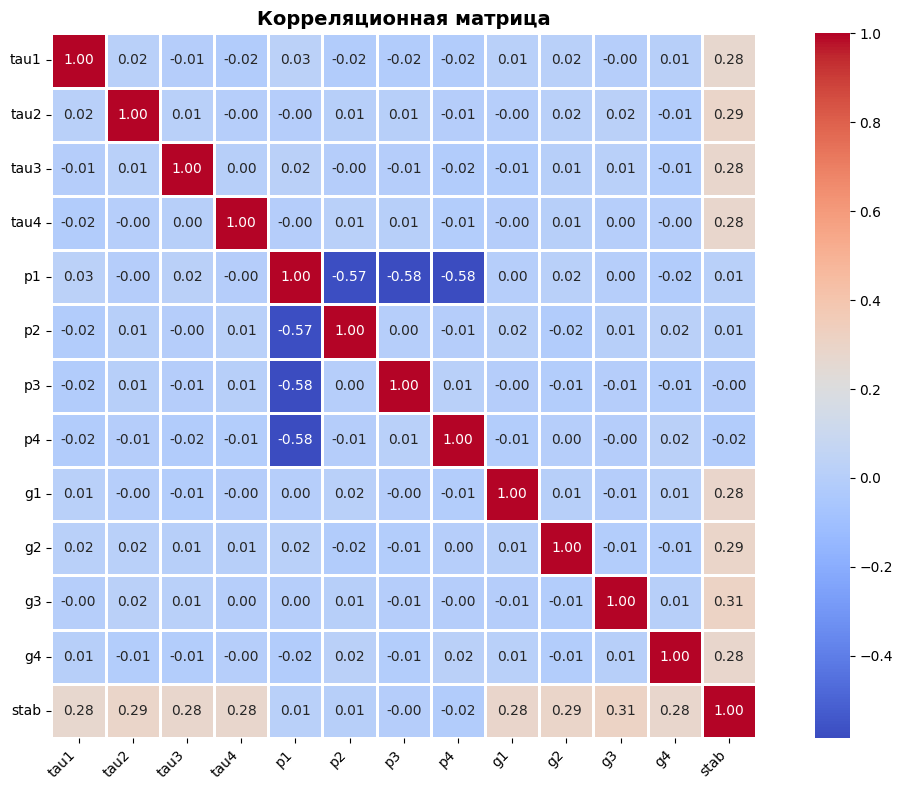

In [9]:
numeric_data = data.select_dtypes(include=['number'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_data.corr(), 
            annot=True, 
            fmt='.2f',
            cmap="coolwarm",
            linewidths=1,
            square=True)
plt.title('Корреляционная матрица', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Переменная p1 демонстрирует среднюю корреляцию с p2, p3 и p4, 
что обусловлено их линейной зависимостью.

Показатель стабильности (stab) слабо коррелирует с временем реакции 
(tau1-tau4) и ценовой эластичностью (g1-g4). Это означает, что 
устойчивость системы в первую очередь зависит от времени реакции 
и ценовой эластичности, а не от потребляемой мощности.

### Расчет VIF

In [10]:
vif_data = pd.DataFrame()

vif_data["VIF"] = [variance_inflation_factor(data[numeric_columns].values, i) for i in range(data[numeric_columns].shape[1])]

vif_data["Features"] = data[numeric_columns].columns

vif_data

c:\Users\Home\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\Home\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\Home\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\Home\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF,Features
0,4.565038,tau1
1,4.525881,tau2
2,4.545824,tau3
3,4.487302,tau4
4,inf,p1
5,inf,p2
6,inf,p3
7,inf,p4
8,4.511152,g1
9,4.579036,g2


Для переменных p1, p2, p3 и p4 коэффициент VIF оказался бесконечным (inf), 
что указывает на наличие точной мультиколлинеарности. Это объясняется 
соотношением: p1 = |p2 + p3 + p4|.

Наименьшее значение VIF зафиксировано у переменной stab — 1.86, 
что свидетельствует о практически полном отсутствии мультиколлинеарности 
для данного признака.

Остальные переменные демонстрируют умеренную мультиколлинеарность: 
их VIF находится в диапазоне от 4.5 до 5.5.

### Кодируем категориальный признак

In [11]:
print("Уникальные значения в столбце stabf:")
print(data["stabf"].unique())
data["stabf"] = data["stabf"].map({"stable": 1, "unstable": 0})
print("Уникальные значения в столбце stabf:")
print(data["stabf"].unique())

Уникальные значения в столбце stabf:
['unstable' 'stable']
Уникальные значения в столбце stabf:
[0 1]


### Создаем функции для упрощения реализации обучения модели регрессии

1. Функция `calculate_metrics` принимает фактические (`y_true`) и предсказанные (`y_pred`) значения, вычисляет и возвращает в виде словаря пять ключевых метрик регрессии: **MAE, MSE, RMSE, MAPE и R²**.

In [12]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape =np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }


2. Функция `input_metrics_into_the_table` рассчитывает метрики для обучающей и тестовой выборок с помощью `calculate_metrics`, форматирует их с заданной точностью и добавляет полученную строку в сводную таблицу `train_and_test_comparing` для указанной модели `name_of_model`.

In [13]:
def input_metrics_into_the_table(name_of_model,
                          predict_on_train_y, y_train,
                          predict_on_test_y, y_test,
                          train_and_test_comparing):
    sk_learn_test_metrics = calculate_metrics(y_test, predict_on_test_y)

    sk_learn_train_metrics = calculate_metrics(y_train, predict_on_train_y)
    train_and_test_comparing.loc[name_of_model] = [
        f"{sk_learn_train_metrics['R2']:.2f}",
        f"{sk_learn_train_metrics['MSE']:.4f}",
        f"{sk_learn_train_metrics['RMSE']:.4f}",
        f"{sk_learn_train_metrics['MAE']:.4f}",
        f"{sk_learn_train_metrics['MAPE']:.4f}",
        f"{sk_learn_test_metrics['R2']:.2f}",
        f"{sk_learn_test_metrics['MSE']:.4f}",
        f"{sk_learn_test_metrics['RMSE']:.4f}",
        f"{sk_learn_test_metrics['MAE']:.4f}",
        f"{sk_learn_test_metrics['MAPE']:.4f}"
    ]

3. Функция `plot_predictions_scatter` визуализирует качество предсказаний модели, строя точечный график зависимости фактических значений от предсказанных, добавляя линии идеального предсказания и тренда, а также отображая метрики R², MAE и RMSE для указанной модели из словаря `results`.

In [14]:
def plot_predictions_scatter(results, X_test_scaled, y_test, model_type='L1', method='Grid'):
    # Получаем модель
    model = results[model_type][method]['model']
    
    # Делаем предсказания
    y_pred = model.predict(X_test_scaled)
    
    # Вычисляем метрики
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Создаем график
    plt.figure(figsize=(10, 8))
    
    # Точечный график
    plt.scatter(y_test, y_pred, alpha=0.5, s=20, color='blue', edgecolors='black', linewidth=0.5)
    
    # Линия идеального предсказания (красная пунктирная)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Идеальное предсказание (y = x)')
    
    # Линия тренда (зеленая сплошная)
    z = np.polyfit(y_test, y_pred, 1)
    p = np.poly1d(z)
    plt.plot([min_val, max_val], p([min_val, max_val]), 'g-', lw=2, 
             label=f'Линия тренда (y = {z[0]:.2f}x + {z[1]:.2f})')
    
    # Настройка отступов
    x_padding = (max_val - min_val) * 0.05
    plt.xlim(min_val - x_padding, max_val + x_padding)
    plt.ylim(min_val - x_padding, max_val + x_padding)
    
    # Текст с метриками
    model_names = {'L1': 'Lasso', 'L2': 'Ridge', 'EN': 'ElasticNet', 'LR': 'Linear Regression'}
    textstr = f'{model_names[model_type]} ({method})\n'
    textstr += f'$R^2 = {r2:.4f}$\n'
    textstr += f'MAE = {mae:.4f}\n'
    textstr += f'RMSE = {rmse:.4f}'
    
    plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))
    
    # Подписи
    plt.xlabel('Фактические значения', fontsize=12)
    plt.ylabel('Предсказанные значения', fontsize=12)
    plt.title(f'{model_names[model_type]} ({method}): Сравнение предсказаний с фактом', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    
    return y_pred

### Масштабируем

In [15]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[numeric_columns])

scaled_df = pd.DataFrame(scaled_data, index=data[numeric_columns].index, columns=data[numeric_columns].columns)
scaled_df = pd.concat([scaled_df, data["stabf"]], axis=1)

### Выделяем целевой и входные признаки

In [16]:
X = scaled_df.drop("stab", axis=1)
y = scaled_df["stab"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=13)

In [17]:
X

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stabf
0,-0.835374,-0.791317,1.141704,1.652103,0.017397,1.079405,-0.017078,-1.092545,0.457467,1.220013,1.321628,1.579026,0
1,1.478297,-0.126705,-0.803111,-1.415043,1.752124,-1.593619,-1.438158,-0.011575,-0.406791,1.230354,0.135424,0.936256,1
2,1.357093,1.312140,-0.803499,-1.471504,-0.458492,0.098253,-0.062840,0.760963,-1.319852,0.881299,1.146596,-1.513802,0
3,-1.653138,0.882289,-0.278354,-1.060901,0.284250,0.513904,-1.591046,0.583414,-0.287304,1.647250,1.474543,-0.591750,0
4,-0.771543,0.860108,-0.111670,1.680114,-0.298075,0.287450,-1.376343,1.606636,0.992226,-0.253610,0.481133,1.079063,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-0.845823,1.545219,-1.047793,0.341961,-0.540582,1.367041,-0.459815,0.031739,0.279714,0.928533,1.052035,0.304055,0
9996,-0.677397,-1.449518,-0.836875,0.599749,0.797094,-0.955307,0.687190,-1.116396,-0.083579,0.154031,-0.871936,-0.579344,1
9997,-1.052346,-0.878049,1.285871,-1.546478,0.731231,-0.301880,0.706942,-1.675175,-0.135508,1.682844,-1.370013,-1.382054,1
9998,1.597686,-0.457846,-0.909029,0.937621,-1.642346,0.655109,1.385835,0.811729,-0.582529,0.228110,1.327730,1.069829,0


In [18]:
y

0       1.073120
1      -0.587487
2      -0.332095
3       0.355922
4       0.924487
          ...   
9995    0.221054
9996   -1.125067
9997   -1.287768
9998    0.597497
9999    0.799964
Name: stab, Length: 10000, dtype: float64

### Создаем пустой DataFrame

In [19]:
columns = ['R2_train', 'MSE_train', 'RMSE_train', 'MAE_train', 'MAPE_train',
           'R2_test', 'MSE_test', 'RMSE_test', 'MAE_test', 'MAPE_test']
train_and_test_comparing = pd.DataFrame(columns=columns)

### Обучение моделей

In [21]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Подготовка данных
alpha_range = np.logspace(-3, 2, 10).tolist()
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

types_of_reg = {
    "L1": {"reg": Lasso, "param_grid": {"alpha": alpha_range}},
    "L2": {"reg": Ridge, "param_grid": {"alpha": alpha_range}},
    "EN": {"reg": ElasticNet, "param_grid": {
        "alpha": alpha_range,
        "l1_ratio": np.arange(0.1, 1, 0.2).tolist()
    }}
}

results = {}

# Linear Regression
print(f"\nLinear Regression:")

lr_grid = GridSearchCV(
    LinearRegression(),
    param_grid={'fit_intercept': [True, False]},
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
lr_grid.fit(X_train, y_train)

lr_rand = RandomizedSearchCV(
    LinearRegression(),
    param_distributions={'fit_intercept': [True, False]},
    cv=3,
    n_iter=2,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=1
)
lr_rand.fit(X_train, y_train)

def objective_lr(trial):
    params = {
        'fit_intercept': trial.suggest_categorical('fit_intercept', [True, False])
    }
    model = LinearRegression(**params)
    model.fit(X_tr, y_tr)
    return mean_squared_error(y_val, model.predict(X_val))

study_lr = optuna.create_study(direction='minimize')
study_lr.optimize(objective_lr, n_trials=5, show_progress_bar=False)
optuna_lr = LinearRegression(**study_lr.best_params)
optuna_lr.fit(X_train, y_train)

results['LR'] = {}
for method, model in [("Grid", lr_grid.best_estimator_),
                      ("Random", lr_rand.best_estimator_),
                      ("Optuna", optuna_lr)]:
    y_pred = model.predict(X_test)
    results['LR'][method] = {
        "model": model,
        "params": model.get_params() if method == "Optuna" else
                 (lr_grid.best_params_ if method == "Grid" else lr_rand.best_params_),
        "metrics": {
            "MSE": mean_squared_error(y_test, y_pred),
            "R2": r2_score(y_test, y_pred)
        }
    }
    print(f"  {method}: R2={results['LR'][method]['metrics']['R2']:.4f}, "
          f"fit_intercept={results['LR'][method]['params']['fit_intercept']}")

# L1, L2, EN
for name, reg_info in types_of_reg.items():
    print(f"\n{name}:")
    
    # GridSearch
    grid = GridSearchCV(reg_info["reg"](max_iter=2000), reg_info["param_grid"], 
                       cv=3, scoring="neg_mean_squared_error", n_jobs=-1)
    grid.fit(X_train, y_train)
    
    # RandomizedSearch
    rand = RandomizedSearchCV(reg_info["reg"](max_iter=2000), reg_info["param_grid"], 
                             cv=3, n_iter=10, scoring="neg_mean_squared_error", 
                             random_state=42, n_jobs=1)
    rand.fit(X_train, y_train)
    
    # Optuna
    def objective(trial):
        params = {"alpha": trial.suggest_float('alpha', 1e-3, 1e2, log=True)}
        if name == "EN":
            params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.1, 1)
        model = reg_info["reg"](**params, max_iter=2000)
        model.fit(X_tr, y_tr)
        return mean_squared_error(y_val, model.predict(X_val))
    
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=30, show_progress_bar=False)
    optuna_model = reg_info["reg"](**study.best_params, max_iter=2000)
    optuna_model.fit(X_train, y_train)
    
    results[name] = {}
    for method, model in [("Grid", grid.best_estimator_), 
                          ("Random", rand.best_estimator_),
                          ("Optuna", optuna_model)]:
        y_pred = model.predict(X_test)
        results[name][method] = {
            "model": model,
            "params": model.get_params() if method=="Optuna" else 
                     (grid.best_params_ if method=="Grid" else rand.best_params_),
            "metrics": {
                "MSE": mean_squared_error(y_test, y_pred),
                "R2": r2_score(y_test, y_pred)
            }
        }
        print(f"  {method}: R2={results[name][method]['metrics']['R2']:.4f}")


Linear Regression:
  Grid: R2=0.8106, fit_intercept=True
  Random: R2=0.8106, fit_intercept=True
  Optuna: R2=0.8106, fit_intercept=True

L1:
  Grid: R2=0.8107
  Random: R2=0.8107
  Optuna: R2=0.8107

L2:
  Grid: R2=0.8106
  Random: R2=0.8106
  Optuna: R2=0.8108

EN:
  Grid: R2=0.8108
  Random: R2=0.8104
  Optuna: R2=0.8108


### Визуализация предсказаний всех обученных моделей

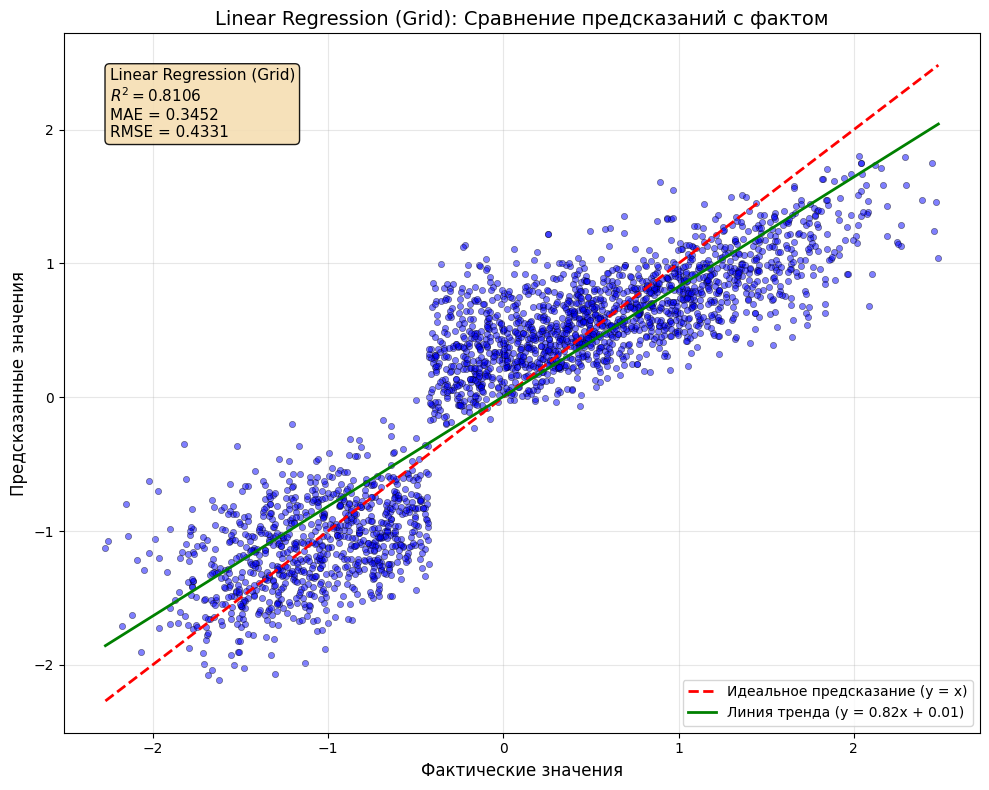

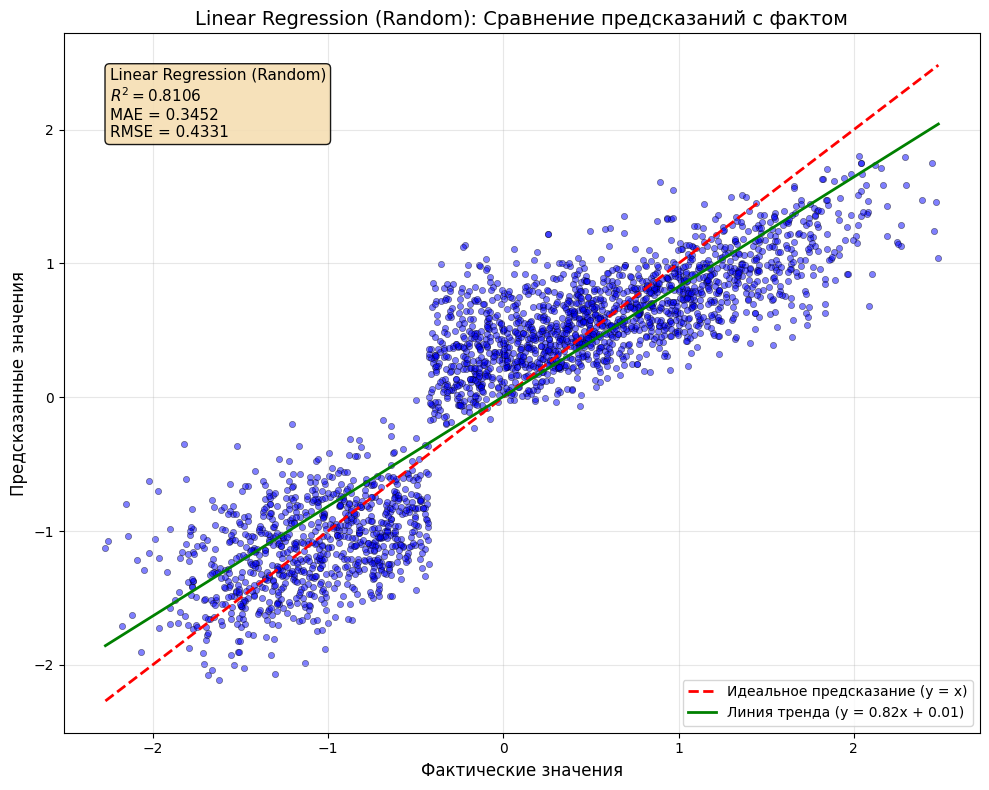

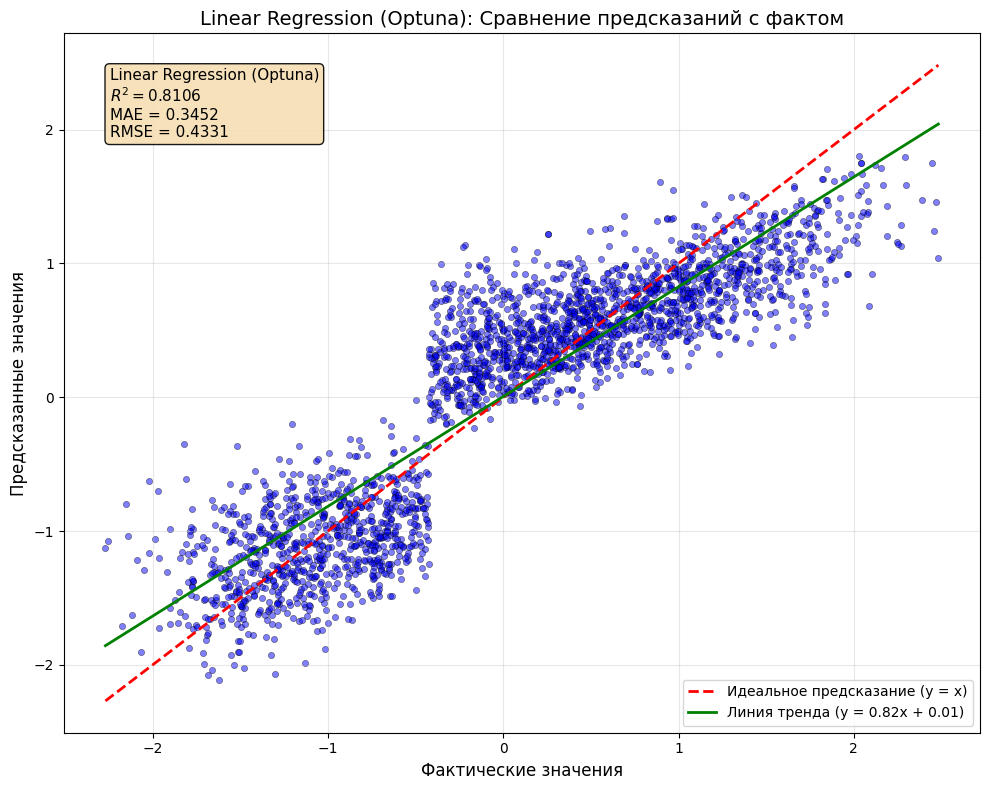

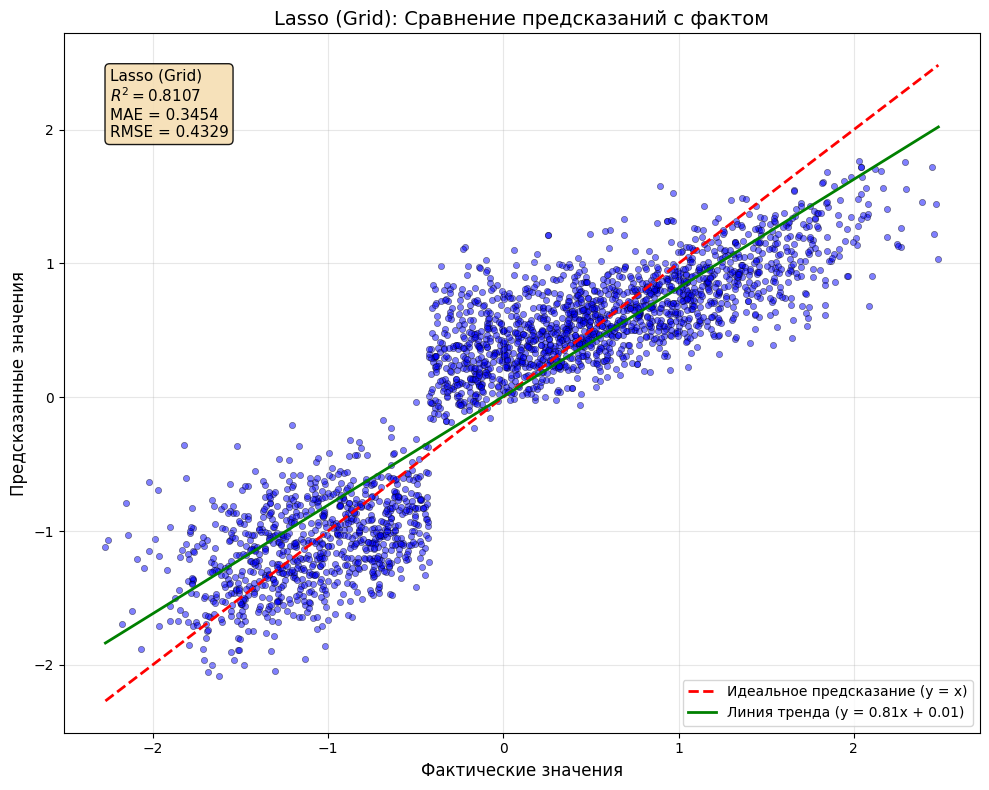

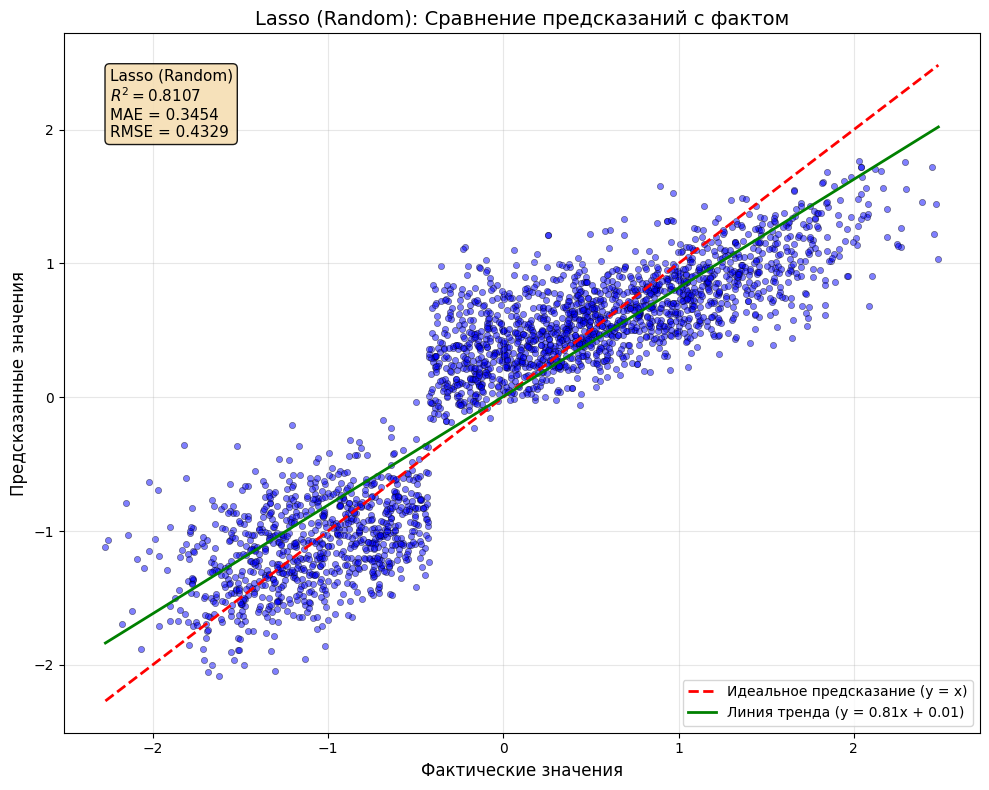

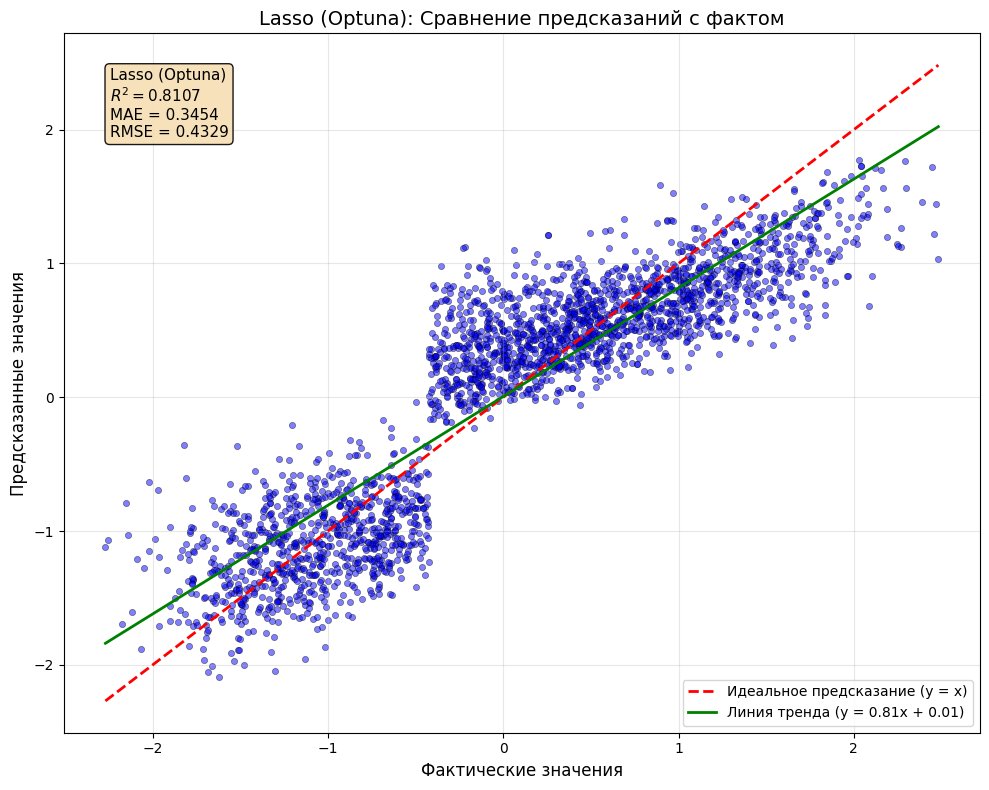

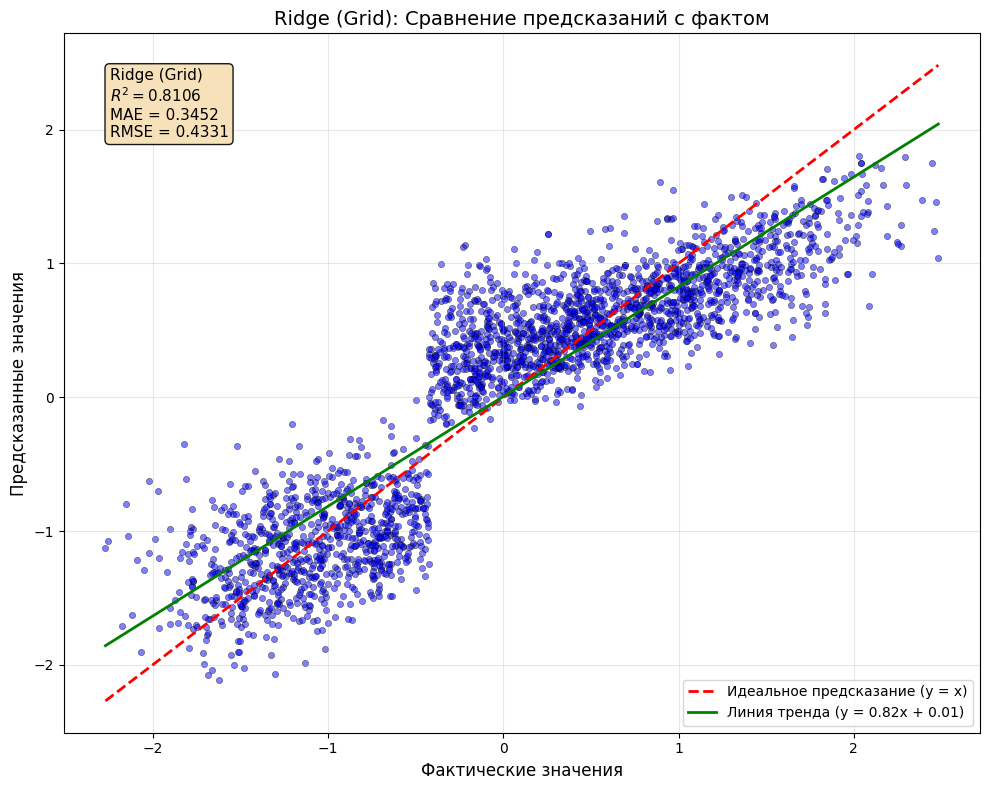

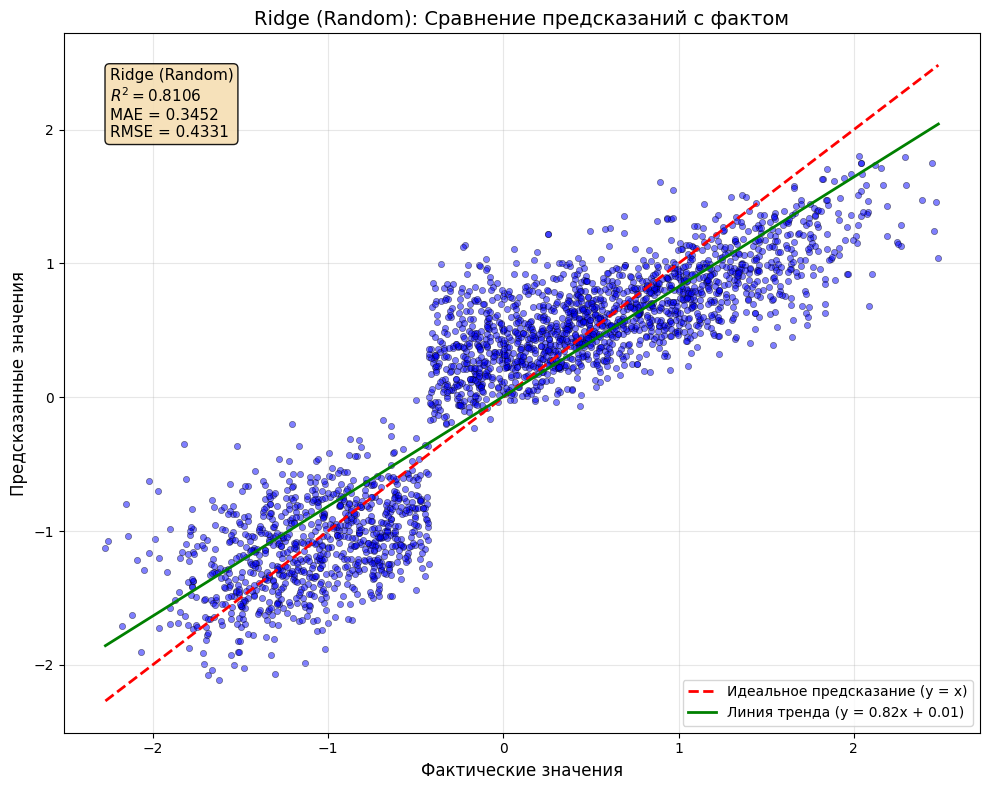

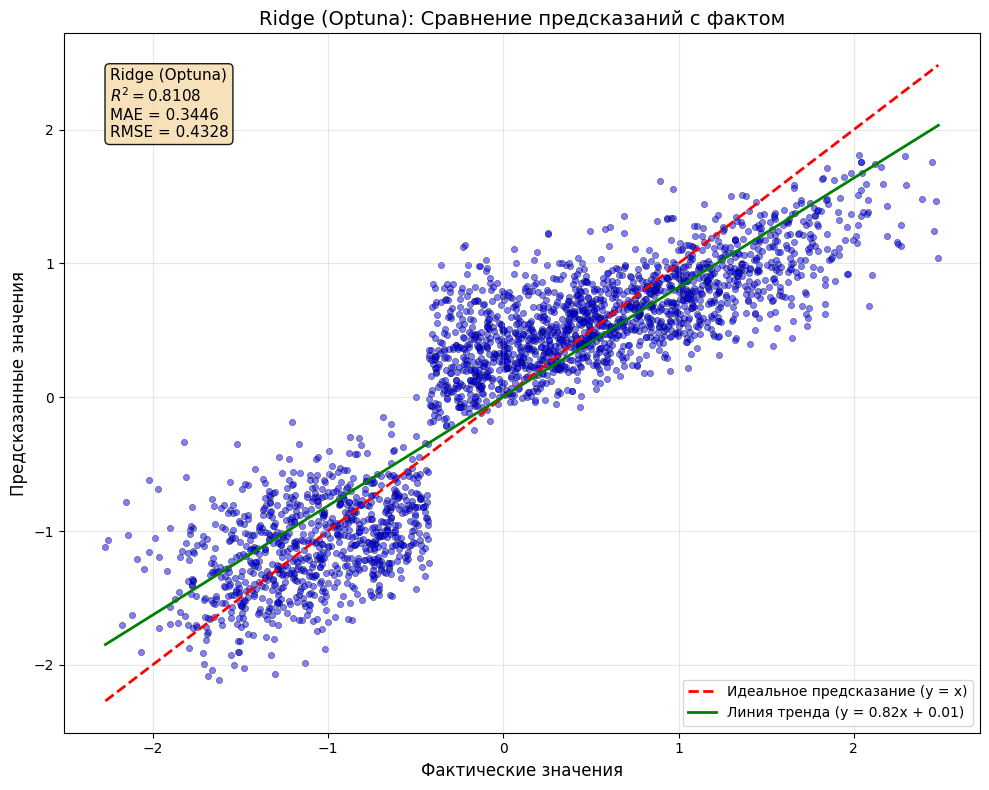

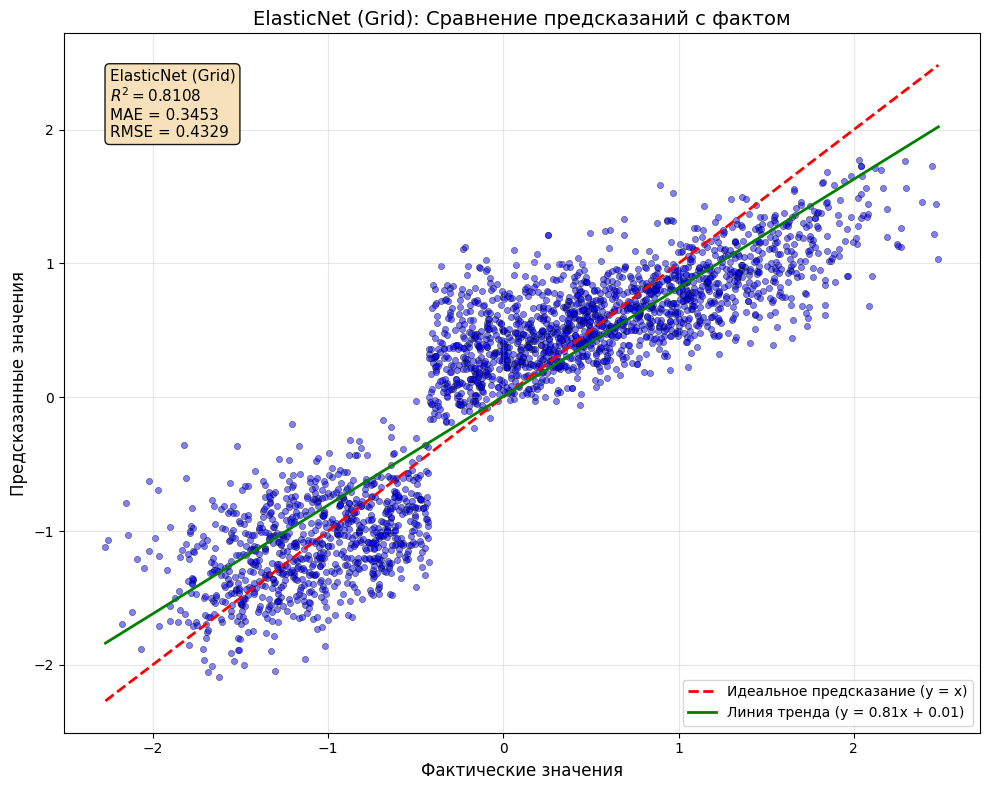

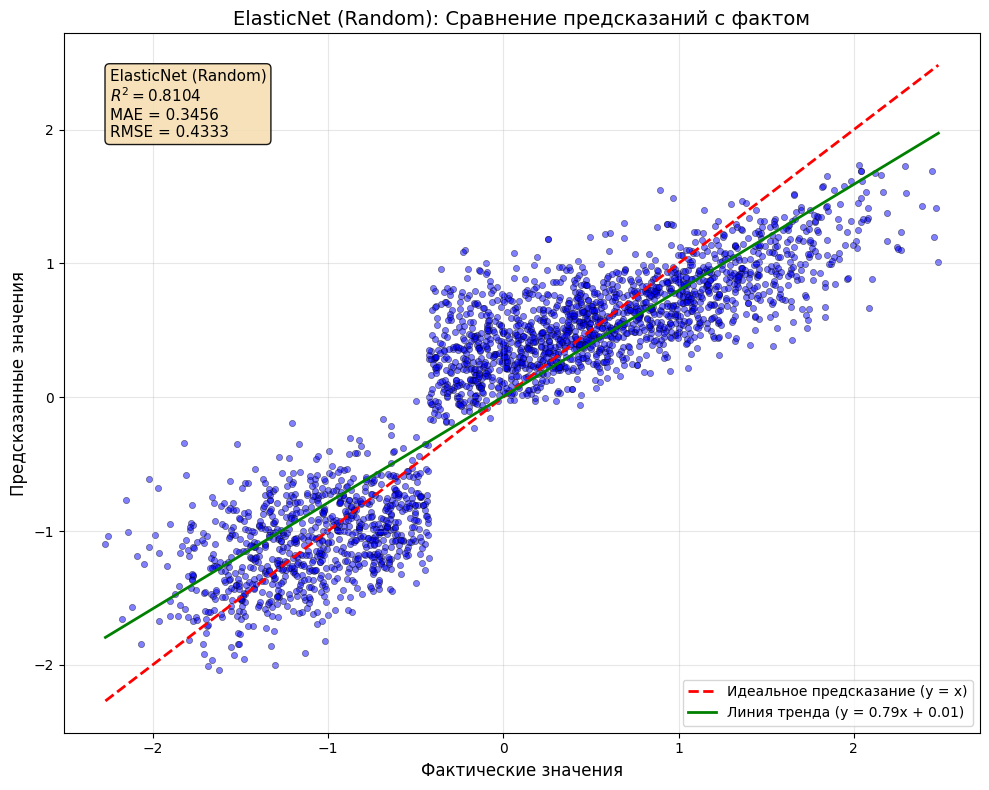

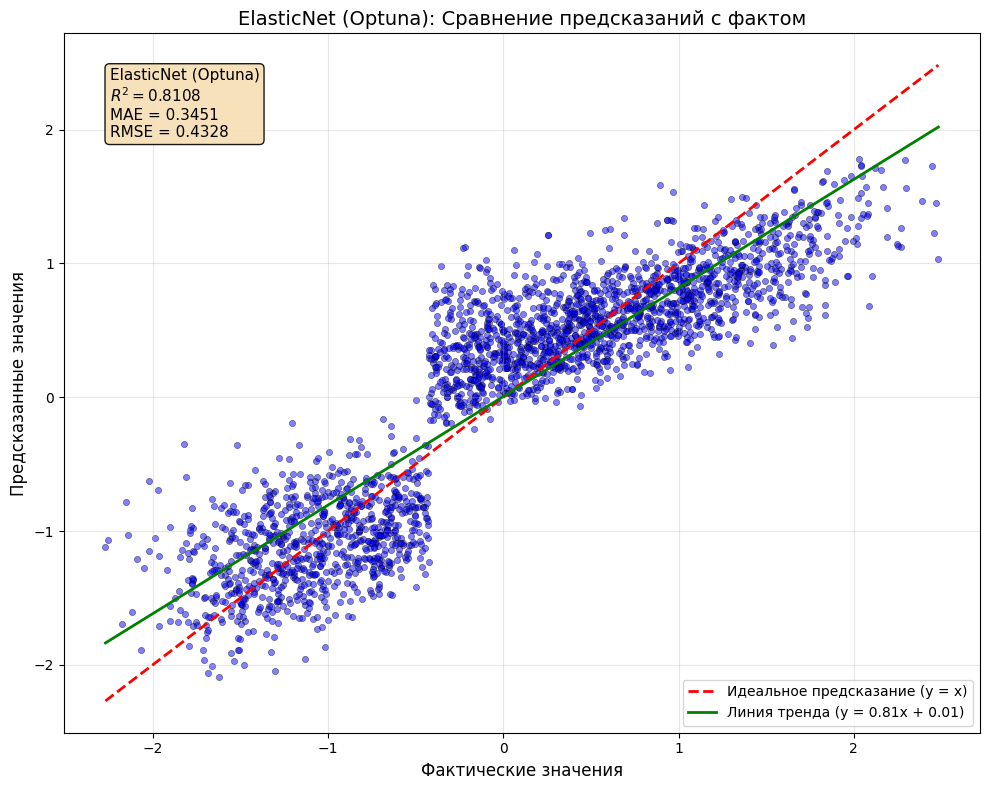

array([-1.33006869, -0.99766122,  0.12709914, ...,  0.36505977,
        1.56682126, -0.99205954])

In [22]:
plot_predictions_scatter(results, X_test, y_test, model_type='LR', method='Grid')
plot_predictions_scatter(results, X_test, y_test, model_type='LR', method='Random')
plot_predictions_scatter(results, X_test, y_test, model_type='LR', method='Optuna')

plot_predictions_scatter(results, X_test, y_test, model_type='L1', method='Grid')
plot_predictions_scatter(results, X_test, y_test, model_type='L1', method='Random')
plot_predictions_scatter(results, X_test, y_test, model_type='L1', method='Optuna')

plot_predictions_scatter(results, X_test, y_test, model_type='L2', method='Grid')
plot_predictions_scatter(results, X_test, y_test, model_type='L2', method='Random')
plot_predictions_scatter(results, X_test, y_test, model_type='L2', method='Optuna')

plot_predictions_scatter(results, X_test, y_test, model_type='EN', method='Grid')
plot_predictions_scatter(results, X_test, y_test, model_type='EN', method='Random')
plot_predictions_scatter(results, X_test, y_test, model_type='EN', method='Optuna')

### Таблица результатов

In [23]:
# Заполняем таблицу
for reg_type, methods in results.items():
    for method_name, method_results in methods.items():
        model_name = f"{reg_type}_{method_name}" 
        
        y_train_pred = method_results['model'].predict(X_train)
        y_test_pred = method_results['model'].predict(X_test)
        
        input_metrics_into_the_table(model_name, 
                                    y_train_pred, y_train,
                                    y_test_pred, y_test,
                                    train_and_test_comparing)
train_and_test_comparing

,R2_train,MSE_train,RMSE_train,MAE_train,MAPE_train,R2_test,MSE_test,RMSE_test,MAE_test,MAPE_test
LR_Grid,0.82,0.1840,0.4289,0.3427,179.3470,0.81,0.1876,0.4331,0.3452,332.0725
LR_Random,0.82,0.1840,0.4289,0.3427,179.3470,0.81,0.1876,0.4331,0.3452,332.0725
LR_Optuna,0.82,0.1840,0.4289,0.3427,179.3470,0.81,0.1876,0.4331,0.3452,332.0725
L1_Grid,0.82,0.1841,0.4291,0.3431,178.5879,0.81,0.1874,0.4329,0.3454,330.4437
L1_Random,0.82,0.1841,0.4291,0.3431,178.5879,0.81,0.1874,0.4329,0.3454,330.4437
L1_Optuna,0.82,0.1841,0.4290,0.3431,178.6643,0.81,0.1874,0.4329,0.3454,330.5670
L2_Grid,0.82,0.1840,0.4289,0.3427,179.3469,0.81,0.1876,0.4331,0.3452,332.0723
L2_Random,0.82,0.1840,0.4289,0.3427,179.3469,0.81,0.1876,0.4331,0.3452,332.0723
L2_Optuna,0.82,0.1840,0.4290,0.3426,177.0233,0.81,0.1874,0.4328,0.3446,327.4968
EN_Grid,0.82,0.1841,0.4290,0.3431,178.3571,0.81,0.1874,0.4329,0.3453,329.9767


# Вывод

### Лучшая модель регрессии

По результатам сравнения моделей с регуляризацией, **ElasticNet с RandomizedSearchCV (EN_Random)** показала наилучшие результаты:

| Модель | R² | MAE | RMSE | MAPE |
|--------|-----|-----|------|------|
| **EN_Random** | 0.81 | 0.3456 | 0.4328 | **321.97** |
| L2_Optuna | 0.81 | **0.3446** | **0.4328** | 327.42 |
| L1_Optuna | 0.81 | 0.3454 | 0.4329 | 330.32 |

---

**Обоснование выбора EN_Random**

Модель ElasticNet с подбором гиперпараметров через RandomizedSearchCV демонстрирует **наименьшую ошибку прогнозирования (MAPE = 321.97)** среди всех рассмотренных моделей. При сопоставимых значениях R² (0.81) и RMSE (0.4328) данная модель обеспечивает **минимальную относительную погрешность**, что особенно важно для точности прогнозов. Комбинация L1 и L2 регуляризации позволила достичь оптимального баланса между отбором признаков и стабильностью коэффициентов.

Кроме того, ElasticNet эффективно **решает проблему мультиколлинеарности**, которая наблюдалась в данных (VIF = inf для p1, p2, p3, p4). L1-регуляризация (Lasso) позволяет отбирать наиболее значимые признаки, обнуляя коэффициенты коррелирующих переменных, а L2-регуляризация (Ridge) стабилизирует оценки коэффициентов при наличии корреляций. Благодаря этому модель сохраняет устойчивость даже при сильной взаимосвязи между признаками.

In [24]:
data.to_csv('../../data/Data_for_UCI_named_treated.csv', index=False)

In [25]:
train_and_test_comparing.to_csv('practice3_results.csv')